In [1]:
import secrets
from tqdm import tqdm

import numpy as np

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms

import nll_to_po.models.dn_policy as Policy
import nll_to_po.models.reward_network as RM
from nll_to_po.training.utils import (
    set_seed_everywhere,
)
import nll_to_po.training.loss as L
import nll_to_po.training.reward as R
from nll_to_po.bilevel.torchopt import run_bilevel_optimization_implicit

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", font_scale=1.2)
sns.set_palette("colorblind")

seed = secrets.randbits(32)
set_seed_everywhere(seed)
print(f"Seed: {seed}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/mnt/data_2/abenechehab/micromamba/envs/nllpo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed: 2614155998


## helper functions

In [17]:
# ---- Utilities ----
def parity_label_from_digit(digit):
    return int(digit % 2 != 0)  # 0 if even, 1 if odd


class FlaggedFlattenedDataset(Dataset):
    """
    Wrap an image dataset (torchvision-like) and return:
    (flattened_tensor_with_flag, label)
    The flag is +1.0 for Parity dataset, -1.0 for Fashion dataset (as requested).
    """

    def __init__(self, base_dataset, is_parity_flag: float):
        self.base = base_dataset
        self.flag = float(is_parity_flag)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        # img: PIL -> to tensor should be performed upstream; torchvision datasets provide tensors if transform set
        # ensure 28x28 -> flatten
        x = img.view(-1).float()  # 784
        # concatenate flag as an extra dimension
        x_flagged = torch.cat([x, torch.tensor([self.flag], dtype=torch.float32)])
        # compute parity label if this is a digit dataset (MNIST); for FashionMNIST label is class and parity is not relevant
        # We'll keep the original digit label as 'digit_label' for building parity correctness
        if self.flag > 0:  # Parity dataset
            return x_flagged, parity_label_from_digit(
                label
            )  # label is 0 if even, 1 if odd
        else:  # Fashion dataset
            return x_flagged, label


def random_subset_indices(dataset_length, n=500, seed=seed):
    rng = np.random.RandomState(seed)
    return rng.choice(dataset_length, size=n, replace=False).tolist()


def evaluate_on_parity_and_fashion(model, parity_loader, fashion_loader, device):
    model.eval()
    # parity: compute parity accuracy (any even/odd digit prediction counts as correct)
    # model outputs logits over 10 digit classes. For parity correctness: predicted_digit %2 == true_parity
    correct_parity = 0
    total_parity = 0
    with torch.no_grad():
        for x_flagged, digit_label in parity_loader:
            x_flagged = x_flagged.to(device)
            logits, _ = model(x_flagged)
            preds = logits.argmax(dim=1).cpu().numpy()
            preds_parity = (
                preds % 2
            )  # parity is derived: parity_label = 1 if odd else 0
            correct_parity += (preds_parity == digit_label).sum()
            total_parity += len(preds)
    parity_acc = correct_parity / total_parity

    # fashion accuracy: predicting the fashion class is not directly comparable to parity, but the authors evaluate
    # prior-task retention by measuring performance on FashionMNIST labels (10-way classification).
    correct_fashion = 0
    total_fashion = 0
    with torch.no_grad():
        for x_flagged, fashion_label in fashion_loader:
            x_flagged = x_flagged.to(device)
            logits, _ = model(x_flagged)
            preds = logits.argmax(dim=1).cpu()
            correct_fashion += (preds == fashion_label).sum().item()
            total_fashion += len(preds)
    fashion_acc = correct_fashion / total_fashion
    model.train()
    return parity_acc, fashion_acc

## Data

In [18]:
# ---- Data loading ----
transform = transforms.Compose([transforms.ToTensor()])  # gives [0,1] float32 tensors

# Download datasets
mnist_train = datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
mnist_test = datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)
fashion_train = datasets.FashionMNIST(
    root="./data", train=True, transform=transform, download=True
)
fashion_test = datasets.FashionMNIST(
    root="./data", train=False, transform=transform, download=True
)

# Create FlaggedFlattenedDataset wrappers
# For pretraining we need small subsets (500 each) as paper describes.
# We'll select random 500 samples for pretraining from train splits.
mnist_subset_idx = random_subset_indices(len(mnist_train), n=500, seed=seed)
fashion_subset_idx = random_subset_indices(len(fashion_train), n=4000, seed=seed)

mnist_subset = Subset(mnist_train, mnist_subset_idx)
fashion_subset = Subset(fashion_train, fashion_subset_idx)

parity_pretrain = FlaggedFlattenedDataset(mnist_subset, is_parity_flag=+1.0)
fashion_pretrain = FlaggedFlattenedDataset(fashion_subset, is_parity_flag=-1.0)

# Held-out validation sets
# We'll use the provided test sets as held-out validation/test sets.
parity_val = FlaggedFlattenedDataset(mnist_test, is_parity_flag=+1.0)
fashion_val = FlaggedFlattenedDataset(fashion_test, is_parity_flag=-1.0)

# Create joint pretrain dataset
pretrain_dataset = ConcatDataset([parity_pretrain, fashion_pretrain])

# DataLoaders
pretrain_loader = DataLoader(pretrain_dataset, batch_size=64, shuffle=True)
parity_val_loader = DataLoader(parity_val, batch_size=256, shuffle=False)
fashion_val_loader = DataLoader(fashion_val, batch_size=256, shuffle=False)

## Fine-tuning helpers

In [ ]:
# ---- Fine-tuning phase on a held-out Parity set ----
def disjoint_subset_indices(total_len, exclude_idx_set, n=2000, seed=seed):
    rng = np.random.RandomState(seed)
    allowed = [i for i in range(total_len) if i not in exclude_idx_set]
    return rng.choice(allowed, size=n, replace=False).tolist()


# Build exclude set from the indices used earlier (mnist_subset_idx)
finetune_idx = disjoint_subset_indices(
    len(mnist_train), set(mnist_subset_idx), n=2000, seed=seed
)
finetune_parity_subset = Subset(mnist_train, finetune_idx)
finetune_parity_dataset = FlaggedFlattenedDataset(
    finetune_parity_subset, is_parity_flag=+1.0
)
finetune_loader = DataLoader(finetune_parity_dataset, batch_size=64, shuffle=True)


# REINFORCE 1-0 implementation (simple)
def reinforce_one_zero_step(
    model,
    optimizer,
    batch_x,
    batch_digit_labels,
    device,
    num_samples=4,
    entropy_coeff=0.0,
    normalize_rewards=False,
):
    """
    GRPO-like REINFORCE with 0-1 parity reward and multiple samples per input.
    - For each x: sample multiple actions y ~ pi(y|x)
    - Reward = 1 if parity(y) == parity(true label), else 0
    - Compute relative (normalized) advantages per input
    - Apply REINFORCE loss with entropy regularization
    """
    model.train()
    batch_x = batch_x.to(device)
    # B = batch_x.size(0)

    # Forward pass to get logits and probs
    logits, probs = model(batch_x)  # [B,10]
    dist = torch.distributions.Categorical(probs=F.softmax(logits, dim=1))

    # Sample multiple actions per input
    sampled_actions = dist.sample((num_samples,))  # [num_samples, B]
    logp_actions = dist.log_prob(sampled_actions)  # [num_samples, B]
    logp_actions = logp_actions.T  # [B, num_samples]

    # === Compute 0-1 parity rewards ===
    true_digits = (
        batch_digit_labels.numpy()
        if isinstance(batch_digit_labels, torch.Tensor)
        else np.array(batch_digit_labels)
    )
    true_parity = (true_digits % 2 != 0).astype(int)

    sampled_actions_np = sampled_actions.T.cpu().numpy()  # [B, num_samples]
    sampled_parity = (sampled_actions_np % 2).astype(int)  # [B, num_samples]

    rewards_np = (sampled_parity == true_parity[:, None]).astype(
        float
    )  # [B, num_samples]
    rewards = torch.tensor(
        rewards_np, dtype=torch.float32, device=device
    )  # [B, num_samples]

    if normalize_rewards and num_samples > 1:
        # === Compute relative advantages (normalize per input) ===
        rewards_mean = rewards.mean(dim=1, keepdim=True)
        rewards_std = rewards.std(dim=1, keepdim=True) + 1e-8
        rewards = (rewards - rewards_mean) / rewards_std
    advantages = rewards  # [B, num_samples]

    # === Policy gradient loss ===
    loss = -(advantages.detach() * logp_actions).mean()

    # === Entropy regularization (for exploration) ===
    entropy = dist.entropy().mean()
    loss = loss - entropy_coeff * entropy

    # === Gradient step ===
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Return average (absolute) reward for logging
    return loss.item(), rewards.mean().item()


# REINFORCE with negative distance reward
def reinforce_reward(
    model,
    optimizer,
    batch_x,
    batch_digit_labels,
    device,
    num_samples=4,
    entropy_coeff=0.0,
    soft_labels=False,
    normalize_rewards=False,
):
    model.train()
    batch_x = batch_x.to(device)
    B = batch_x.size(0)

    true_digits = (
        batch_digit_labels.numpy()
        if isinstance(batch_digit_labels, torch.Tensor)
        else np.array(batch_digit_labels)
    )
    parity = (true_digits % 2 != 0).astype(int)
    labels = torch.zeros((B, 10), device=device)
    if soft_labels:
        # === Build soft parity-based label distribution ===
        even_mask = torch.tensor([0, 2, 4, 6, 8], device=device)
        odd_mask = torch.tensor([1, 3, 5, 7, 9], device=device)
        for i, p in enumerate(parity):
            if p == 0:
                labels[i, even_mask] = 1.0 / len(even_mask)
            else:
                labels[i, odd_mask] = 1.0 / len(odd_mask)
    else:
        # === Build hard parity-based label distribution (one-hot) ===
        for i, p in enumerate(parity):
            if p == 0:
                labels[i, 0] = 1.0  # 0 for even
            else:
                labels[i, 1] = 1.0  # 1 for odd

    # === Forward pass: get logits and base distribution ===
    _, probs = model(batch_x)  # logits: [B,10]
    dist = torch.distributions.Categorical(probs=probs)

    # === Sample multiple actions per input ===
    sampled_actions = dist.sample((num_samples,))  # [num_samples, B]
    logp_actions = dist.log_prob(sampled_actions)  # [num_samples, B]
    logp_actions = logp_actions.T  # [B, num_samples]

    # === Compute rewards for each sampled action ===
    # We'll build one-hot for each action to compute "predicted distribution"
    one_hot_samples = F.one_hot(
        sampled_actions.T, num_classes=10
    ).float()  # [B, num_samples, 10]
    # reward = -Euclidean distance between one-hot and soft_labels
    distances = torch.norm(
        one_hot_samples - labels.unsqueeze(1), dim=2
    )  # [B, num_samples]
    rewards = -distances  # higher is better (closer to soft parity dist)

    if normalize_rewards and num_samples > 1:
        # === Compute relative advantages (normalize per input) ===
        rewards_mean = rewards.mean(dim=1, keepdim=True)
        rewards_std = rewards.std(dim=1, keepdim=True) + 1e-8
        rewards = (rewards - rewards_mean) / rewards_std
    advantages = rewards  # [B, num_samples]

    # === Compute policy gradient loss ===
    loss = -(advantages.detach() * logp_actions).mean()

    # === Optional entropy regularization ===
    entropy = dist.entropy().mean()
    loss = loss - entropy_coeff * entropy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Return mean reward for logging
    return loss.item(), rewards.mean().item()


# SFT parity fine-tune step
def sft_parity_step(
    model,
    optimizer,
    batch_x,
    batch_digit_labels,
    device,
    mapping_even_to_digit=0,
    mapping_odd_to_digit=1,
    soft_labels=False,
):
    # map parity to an arbitrary canonical digit label that represents the parity class
    # targets shall be integers 0..9
    true_digits = (
        batch_digit_labels.numpy()
        if isinstance(batch_digit_labels, torch.Tensor)
        else np.array(batch_digit_labels)
    )
    parity = (true_digits % 2 != 0).astype(int)

    logits, _ = model(batch_x.to(device))

    if not soft_labels:
        # supervised labels: even->mapping_even_to_digit, odd->mapping_odd_to_digit
        targets = torch.tensor(
            [mapping_odd_to_digit if p == 1 else mapping_even_to_digit for p in parity],
            dtype=torch.long,
            device=device,
        )
        loss = F.cross_entropy(logits, targets)
    else:
        # soft labels: even->equal weights for all even numbers (0,2,4,6,8); odd->equal weights for all odd numbers (1,3,5,7,9)
        soft_labels = torch.zeros((len(true_digits), 10), device=device)
        even_mask = torch.tensor([0, 2, 4, 6, 8], device=device)
        odd_mask = torch.tensor([1, 3, 5, 7, 9], device=device)
        for i, p in enumerate(parity):
            if p == 0:
                soft_labels[i, even_mask] = 1.0 / len(even_mask)
            else:
                soft_labels[i, odd_mask] = 1.0 / len(odd_mask)
        log_probs = F.log_softmax(logits, dim=1)
        loss = -(soft_labels * log_probs).sum(dim=1).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # compute parity accuracy after step for logging (using logits argmax parity)
    preds = logits.argmax(dim=1).cpu().numpy()
    preds_parity = preds % 2
    acc = (preds_parity == parity).mean()
    return loss.item(), acc


# Reset model to base state for fine-tuning runs
def load_base_state(model, base_state):
    # expects base_state to be cpu tensors dictionary
    model.load_state_dict({k: v.clone() for k, v in base_state.items()})
    model.to(device)

## Full loop: Pre-training + Fine-tuning (SFT, RL with oracle reward, RL with neg distance reward)

In [ ]:
# ---- Multiple Experiments ----
N_experiments: int = 3
pretraining_epochs: int = 15
# Fine-tuning configuration
fine_tuning_epochs: int = 15
log_every: int = 25
num_samples: int = 5
soft_labels: bool = False
entropy_coeff: float = 0.0
normalize_rewards: bool = True

# Storage for all runs
all_runs = {
    "seeds": [],
    "pretrain_parity_accs": [],
    "pretrain_fashion_accs": [],
    "sft_history": [],
    "rl_history": [],
    "rl_reward_history": [],
}

for run_idx in range(N_experiments):
    print(f"\n{'=' * 60}")
    print(f"Starting Run {run_idx + 1}/{N_experiments}")
    print(f"{'=' * 60}\n")

    # Set new seed for this run
    seed = secrets.randbits(32)
    set_seed_everywhere(seed)
    all_runs["seeds"].append(seed)

    # ---- Pretraining ----
    model = Policy.MulticlassMLP(
        input_dim=785, hidden_sizes=[512, 256], output_dim=10
    ).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

    # Evaluate before training to get initial accuracy
    parity_acc_init, fashion_acc_init = evaluate_on_parity_and_fashion(
        model, parity_val_loader, fashion_val_loader, device
    )
    pretrain_parity_accs, pretrain_fashion_accs = [parity_acc_init], [fashion_acc_init]

    # Pretrain loop (few epochs)
    print("Pretraining on small joint dataset (ParityMNIST + FashionMNIST subsets)")
    pretrain_parity_accs, pretrain_fashion_accs = [], []
    for epoch in tqdm(range(pretraining_epochs), desc=f"Run {run_idx + 1} Pretrain"):
        model.train()
        for x_flagged, digit_label in pretrain_loader:
            x_flagged = x_flagged.to(device)
            targets = digit_label.to(device)
            logits, _ = model(x_flagged)
            loss = F.cross_entropy(logits, targets)
            opt.zero_grad()
            loss.backward()
            opt.step()
        # validation
        parity_acc, fashion_acc = evaluate_on_parity_and_fashion(
            model, parity_val_loader, fashion_val_loader, device
        )
        pretrain_parity_accs.append(parity_acc)
        pretrain_fashion_accs.append(fashion_acc)

    # Save results for this run
    all_runs["pretrain_parity_accs"].append(pretrain_parity_accs)
    all_runs["pretrain_fashion_accs"].append(pretrain_fashion_accs)

    # Save base model (pi0)
    base_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Run 1: SFT fine-tuning (canonical mapping even->0 odd->1)
    print(
        f"\n[Run {run_idx + 1}] Fine-tuning with SFT (canonical mapping even->0 odd->1) ..."
    )
    load_base_state(model, base_model_state)
    opt_ft = torch.optim.AdamW(model.parameters(), lr=2e-4)

    sft_history = {
        "step": [],
        "parity_val_acc": [],
        "fashion_val_acc": [],
        "parity_train_acc": [],
    }

    step = 0
    for epoch in tqdm(range(fine_tuning_epochs), desc=f"Run {run_idx + 1} SFT"):
        for x_flagged, digit_label in finetune_loader:
            loss_val, train_parity_acc = sft_parity_step(
                model, opt_ft, x_flagged, digit_label, device, soft_labels=soft_labels
            )
        step += 1
        p_acc, f_acc = evaluate_on_parity_and_fashion(
            model, parity_val_loader, fashion_val_loader, device
        )
        sft_history["step"].append(step)
        sft_history["parity_val_acc"].append(p_acc)
        sft_history["fashion_val_acc"].append(f_acc)
        sft_history["parity_train_acc"].append(train_parity_acc)
        if step % log_every == 0:
            print(
                f"[SFT Run {run_idx + 1}] step {step} epoch {epoch + 1}: parity_val={p_acc:.4f}, fashion_val={f_acc:.4f}, train_parity_est={train_parity_acc:.4f}"
            )

    all_runs["sft_history"].append(sft_history)

    # Run 2: REINFORCE 1-0 fine-tuning
    print(f"\n[Run {run_idx + 1}] Fine-tuning with 1-0 REINFORCE ...")
    load_base_state(model, base_model_state)
    opt_rl = torch.optim.AdamW(model.parameters(), lr=2e-4)

    rl_history = {
        "step": [],
        "parity_val_acc": [],
        "fashion_val_acc": [],
        "mean_reward": [],
    }

    step = 0
    for epoch in tqdm(range(fine_tuning_epochs), desc=f"Run {run_idx + 1} RL 1-0"):
        for x_flagged, digit_label in finetune_loader:
            loss_rl, mean_reward = reinforce_one_zero_step(
                model,
                opt_rl,
                x_flagged,
                digit_label,
                device,
                num_samples=num_samples,
                entropy_coeff=entropy_coeff,
                normalize_rewards=normalize_rewards,
            )
        step += 1
        p_acc, f_acc = evaluate_on_parity_and_fashion(
            model, parity_val_loader, fashion_val_loader, device
        )
        rl_history["step"].append(step)
        rl_history["parity_val_acc"].append(p_acc)
        rl_history["fashion_val_acc"].append(f_acc)
        rl_history["mean_reward"].append(mean_reward)
        if step % log_every == 0:
            print(
                f"[RL Run {run_idx + 1}] step {step} epoch {epoch + 1}: parity_val={p_acc:.4f}, fashion_val={f_acc:.4f}, mean_reward={mean_reward:.4f}"
            )

    all_runs["rl_history"].append(rl_history)

    # Run 3: REINFORCE negative distance reward fine-tuning
    print(f"\n[Run {run_idx + 1}] Fine-tuning with negative distance REINFORCE ...")
    load_base_state(model, base_model_state)
    opt_rew = torch.optim.AdamW(model.parameters(), lr=2e-4)

    rl_reward_history = {
        "step": [],
        "parity_val_acc": [],
        "fashion_val_acc": [],
        "mean_reward": [],
    }

    step = 0
    for epoch in tqdm(range(fine_tuning_epochs), desc=f"Run {run_idx + 1} RL Reward"):
        for x_flagged, digit_label in finetune_loader:
            loss_rl, mean_reward = reinforce_reward(
                model,
                opt_rew,
                x_flagged,
                digit_label,
                device,
                num_samples=num_samples,
                soft_labels=soft_labels,
                entropy_coeff=entropy_coeff,
                normalize_rewards=normalize_rewards,
            )
        step += 1
        p_acc, f_acc = evaluate_on_parity_and_fashion(
            model, parity_val_loader, fashion_val_loader, device
        )
        rl_reward_history["step"].append(step)
        rl_reward_history["parity_val_acc"].append(p_acc)
        rl_reward_history["fashion_val_acc"].append(f_acc)
        rl_reward_history["mean_reward"].append(mean_reward)
        if step % log_every == 0:
            print(
                f"[RL Reward Run {run_idx + 1}] step {step} epoch {epoch + 1}: parity_val={p_acc:.4f}, fashion_val={f_acc:.4f}, mean_reward={mean_reward:.4f}"
            )

    all_runs["rl_reward_history"].append(rl_reward_history)

    print(f"\nCompleted Run {run_idx + 1}/{N_experiments}")

print(f"\n{'=' * 60}")
print(f"All {N_experiments} experiments completed!")
print(f"{'=' * 60}")


Starting Run 1/3

Pretraining on small joint dataset (ParityMNIST + FashionMNIST subsets)


Run 1 Pretrain: 100%|██████████| 15/15 [00:19<00:00,  1.33s/it]



[Run 1] Fine-tuning with SFT (canonical mapping even->0 odd->1) ...


Run 1 SFT: 100%|██████████| 15/15 [00:17<00:00,  1.18s/it]



[Run 1] Fine-tuning with 1-0 REINFORCE ...


...


[Run 3] Fine-tuning with 1-0 REINFORCE ...


Run 3 RL 1-0: 100%|██████████| 15/15 [00:18<00:00,  1.24s/it]



[Run 3] Fine-tuning with negative distance REINFORCE ...


Run 3 RL Reward: 100%|██████████| 15/15 [00:20<00:00,  1.35s/it]


Completed Run 3/3

All 3 experiments completed!


## Plots

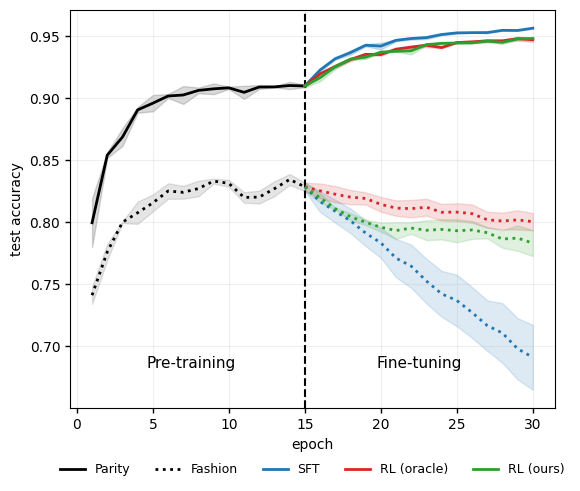

In [ ]:
# --- Helper functions ---
def mean_sem(arr_list):
    """Return (mean, standard error) arrays given list of 1D arrays."""
    arr = np.array(arr_list, dtype=float)
    min_len = min(len(a) for a in arr_list)
    arr = np.stack([a[:min_len] for a in arr_list], axis=0)
    mean = np.mean(arr, axis=0)
    sem = np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])
    return mean, sem


def avg_history(histories, key):
    vals = [np.array(h[key]) for h in histories]
    min_len = min(len(v) for v in vals)
    vals = [v[:min_len] for v in vals]
    return vals  # return list of arrays to compute mean + sem later


# --- Compute means and SEMs ---

# Pretraining
pretrain_parity_mean, pretrain_parity_sem = mean_sem(all_runs["pretrain_parity_accs"])
pretrain_fashion_mean, pretrain_fashion_sem = mean_sem(
    all_runs["pretrain_fashion_accs"]
)

# Fine-tuning
sft_parity_vals = avg_history(all_runs["sft_history"], "parity_val_acc")
sft_fashion_vals = avg_history(all_runs["sft_history"], "fashion_val_acc")

rl_parity_vals = avg_history(all_runs["rl_history"], "parity_val_acc")
rl_fashion_vals = avg_history(all_runs["rl_history"], "fashion_val_acc")

rlr_parity_vals = avg_history(all_runs["rl_reward_history"], "parity_val_acc")
rlr_fashion_vals = avg_history(all_runs["rl_reward_history"], "fashion_val_acc")

sft_parity_mean, sft_parity_sem = mean_sem(sft_parity_vals)
sft_fashion_mean, sft_fashion_sem = mean_sem(sft_fashion_vals)

rl_parity_mean, rl_parity_sem = mean_sem(rl_parity_vals)
rl_fashion_mean, rl_fashion_sem = mean_sem(rl_fashion_vals)

rlr_parity_mean, rlr_parity_sem = mean_sem(rlr_parity_vals)
rlr_fashion_mean, rlr_fashion_sem = mean_sem(rlr_fashion_vals)

# --- Build axes ---
pre_epochs = len(pretrain_parity_mean)
fine_epochs = len(sft_parity_mean)
x_pre = np.arange(pre_epochs + 1)
x_fine = np.arange(pre_epochs, pre_epochs + fine_epochs + 1)

# --- Plot style ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(6, 5))

# === Pretraining ===
ax.plot(x_pre, pretrain_parity_mean, color="black", linewidth=2.0, label="Parity")
ax.fill_between(
    x_pre,
    pretrain_parity_mean - pretrain_parity_sem,
    pretrain_parity_mean + pretrain_parity_sem,
    color="black",
    alpha=0.15,
)

ax.plot(
    x_pre,
    pretrain_fashion_mean,
    color="black",
    linewidth=2.0,
    linestyle=":",
    label="Fashion",
)
ax.fill_between(
    x_pre,
    pretrain_fashion_mean - pretrain_fashion_sem,
    pretrain_fashion_mean + pretrain_fashion_sem,
    color="black",
    alpha=0.1,
)

# Vertical dashed line
ax.axvline(x=pre_epochs, color="black", linestyle="--", linewidth=1.5)

# === Fine-tuning ===
colors = {
    "SFT": "#1f77b4",  # blue
    "RL 0-1": "#d62728",  # green
    "RL reward": "#2ca02c",  # red
}

# Parity (solid)
for label, mean, sem, color in [
    ("SFT", sft_parity_mean, sft_parity_sem, colors["SFT"]),
    ("RL (oracle)", rl_parity_mean, rl_parity_sem, colors["RL 0-1"]),
    ("RL (ours)", rlr_parity_mean, rlr_parity_sem, colors["RL reward"]),
]:
    # Prepend last pretraining value
    mean_with_pretrain = np.concatenate([[pretrain_parity_mean[-1]], mean])
    sem_with_pretrain = np.concatenate([[pretrain_parity_sem[-1]], sem])
    ax.plot(x_fine, mean_with_pretrain, color=color, linewidth=2.0, label=label)
    ax.fill_between(
        x_fine,
        mean_with_pretrain - sem_with_pretrain,
        mean_with_pretrain + sem_with_pretrain,
        color=color,
        alpha=0.2,
    )

# Fashion (dotted)
for label, mean, sem, color in [
    ("SFT", sft_fashion_mean, sft_fashion_sem, colors["SFT"]),
    ("RL (oracle)", rl_fashion_mean, rl_fashion_sem, colors["RL 0-1"]),
    ("RL (ours)", rlr_fashion_mean, rlr_fashion_sem, colors["RL reward"]),
]:
    # Prepend last pretraining value
    mean_with_pretrain = np.concatenate([[pretrain_fashion_mean[-1]], mean])
    sem_with_pretrain = np.concatenate([[pretrain_fashion_sem[-1]], sem])
    ax.plot(x_fine, mean_with_pretrain, color=color, linewidth=2.0, linestyle=":")
    ax.fill_between(
        x_fine,
        mean_with_pretrain - sem_with_pretrain,
        mean_with_pretrain + sem_with_pretrain,
        color=color,
        alpha=0.15,
    )

# --- Decorations ---
ax.set_xlabel("epoch", fontsize=10)
ax.set_ylabel("test accuracy", fontsize=10)
# ax.set_title("Pre-training and Fine-tuning Phases", fontsize=13, pad=10)

# Phase text
ax.text(pre_epochs / 2, 0.68, "Pre-training", ha="center", va="bottom", fontsize=11)
ax.text(
    pre_epochs + fine_epochs / 2,
    0.68,
    "Fine-tuning",
    ha="center",
    va="bottom",
    fontsize=11,
)

# Grid & style
ax.grid(True, alpha=0.2)
ax.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_color("black")
ax.tick_params(colors="black", direction="out", width=1)

# Legend
ax.legend(
    frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=5
)

plt.tight_layout()
plt.show()

## implicit diff

#### parameters

In [40]:
train_loader: DataLoader = finetune_loader
val_loader: DataLoader = parity_val_loader
input_dim: int = 785
num_classes: int = 10
nll_loss_constructor: L.LossFunction = L.FuncNLL_Classification
pg_loss_constructor: L.LossFunction = L.FuncPG_Classification
reward_fn_constructor: R.RewardFunction = R.FuncOneHotRewardNetwork
policy_model_constructor: torch.nn.Module = Policy.MulticlassMLP
n_outer_epochs: int = 10
n_inner_epochs: int = 15
inner_lr: float = 2e-4
outer_lr: float = 1e-1
entropy_weight: float = 0.0
n_generations: int = 5
outer_scheduler_patience: int = 0
early_stopping_patience: int = 0
reward_init_param: float = 1.0
reward_use_softplus: bool = False
reward_network = RM.RewardMLPMahalanobisDiag(
    input_dim=num_classes,
    init_param=reward_init_param,
    use_softplus=reward_use_softplus,
)

#### bilevel imp diff

In [ ]:
# Run the bilevel optimization
(
    train_accuracy,
    val_accuracy,
    outer_losses,
    val_outer_losses,
    inner_losses,
    inner_rewards,
    U_coeff,
    U_coeff_grad,
) = run_bilevel_optimization_implicit(
    train_loader=train_loader,
    val_loader=val_loader,
    num_classes=num_classes,
    input_dim=input_dim,
    policy_model_constructor=policy_model_constructor,
    nll_loss_constructor=nll_loss_constructor,
    pg_loss_constructor=pg_loss_constructor,
    reward_fn_constructor=reward_fn_constructor,
    n_outer_epochs=n_outer_epochs,
    n_inner_epochs=n_inner_epochs,
    inner_lr=inner_lr,
    outer_lr=outer_lr,
    device=device,
    entropy_weight=entropy_weight,
    n_generations=n_generations,
    outer_scheduler_patience=outer_scheduler_patience,
    early_stopping_patience=early_stopping_patience,
    reward_network=reward_network,
    policy_base_state=base_model_state,
)

In [41]:
# Experiment parameters
max_repetitions = 1
max_tolerated_crashes = 10

# Storage for all runs
all_train_accuracies = []
all_val_accuracies = []
all_outer_losses = []
all_val_outer_losses = []
all_inner_losses = []
all_inner_rewards = []
all_U_coeff = []
all_U_coeff_grad = []

successful_runs = 0
crashes = 0

for rep in range(max_repetitions):
    if crashes >= max_tolerated_crashes:
        print(
            f"Maximum tolerated crashes ({max_tolerated_crashes}) reached. Stopping experiments."
        )
        break

    try:
        print(f"Running experiment {rep + 1}/{max_repetitions}...")

        # Run the bilevel optimization
        (
            train_accuracy,
            val_accuracy,
            outer_losses,
            val_outer_losses,
            inner_losses,
            inner_rewards,
            U_coeff,
            U_coeff_grad,
        ) = run_bilevel_optimization_implicit(
            train_loader=train_loader,
            val_loader=val_loader,
            num_classes=num_classes,
            input_dim=input_dim,
            policy_model_constructor=policy_model_constructor,
            nll_loss_constructor=nll_loss_constructor,
            pg_loss_constructor=pg_loss_constructor,
            reward_fn_constructor=reward_fn_constructor,
            n_outer_epochs=n_outer_epochs,
            n_inner_epochs=n_inner_epochs,
            inner_lr=inner_lr,
            outer_lr=outer_lr,
            device=device,
            entropy_weight=entropy_weight,
            n_generations=n_generations,
            outer_scheduler_patience=outer_scheduler_patience,
            early_stopping_patience=early_stopping_patience,
            reward_network=reward_network,
            policy_base_state=base_model_state,
        )

        # Store results
        all_train_accuracies.append(train_accuracy)
        all_val_accuracies.append(val_accuracy)
        all_outer_losses.append(outer_losses)
        all_val_outer_losses.append(val_outer_losses)
        all_inner_losses.append(inner_losses)
        all_inner_rewards.append(inner_rewards)
        all_U_coeff.append(U_coeff)
        all_U_coeff_grad.append(U_coeff_grad)

        successful_runs += 1
        print(f"Experiment {rep + 1} completed successfully.")

    except Exception as e:
        crashes += 1
        print(f"Experiment {rep + 1} crashed: {str(e)}")
        print(f"Crashes so far: {crashes}/{max_tolerated_crashes}")
        continue

print(f"Completed {successful_runs} successful runs out of {max_repetitions} attempts.")

# Convert to numpy arrays for easier computation
all_train_accuracies = np.array(all_train_accuracies)
all_val_accuracies = np.array(all_val_accuracies)
all_outer_losses = np.array(all_outer_losses)
all_val_outer_losses = np.array(all_val_outer_losses)


# Process U_coeff and U_coeff_grad dictionaries
# Extract parameter names from first successful run
param_names = list(all_U_coeff[0].keys())

# Convert dictionary data to arrays for each parameter
U_coeff_arrays = {}
U_coeff_grad_arrays = {}

for param_name in param_names:
    # Extract data for this parameter across all runs
    U_coeff_data = [run_data[param_name] for run_data in all_U_coeff]
    U_coeff_grad_data = [run_data[param_name] for run_data in all_U_coeff_grad]

    U_coeff_arrays[param_name] = np.array(U_coeff_data)
    U_coeff_grad_arrays[param_name] = np.array(U_coeff_grad_data)

# Flatten inner rewards for averaging
all_inner_rewards_flat = []
for run in all_inner_rewards:
    flat_rewards = []
    for outer_epoch in run:
        flat_rewards.extend(outer_epoch)
    all_inner_rewards_flat.append(flat_rewards)
all_inner_rewards_flat = np.array(all_inner_rewards_flat)

# Compute statistics
train_accuracies_mean = np.mean(all_train_accuracies, axis=0)
train_accuracies_std = np.std(all_train_accuracies, axis=0)
train_accuracies_se = train_accuracies_std / np.sqrt(successful_runs)

val_accuracies_mean = np.mean(all_val_accuracies, axis=0)
val_accuracies_std = np.std(all_val_accuracies, axis=0)
val_accuracies_se = val_accuracies_std / np.sqrt(successful_runs)

outer_losses_mean = np.mean(all_outer_losses, axis=0)
outer_losses_std = np.std(all_outer_losses, axis=0)
outer_losses_se = outer_losses_std / np.sqrt(successful_runs)

val_outer_losses_mean = np.mean(all_val_outer_losses, axis=0)
val_outer_losses_std = np.std(all_val_outer_losses, axis=0)
val_outer_losses_se = val_outer_losses_std / np.sqrt(successful_runs)

# Compute statistics for U_coeff and U_coeff_grad for each parameter
U_coeff_mean = {}
U_coeff_std = {}
U_coeff_se = {}
U_coeff_grad_mean = {}
U_coeff_grad_std = {}
U_coeff_grad_se = {}

for param_name in param_names:
    U_coeff_mean[param_name] = np.mean(U_coeff_arrays[param_name], axis=0)
    U_coeff_std[param_name] = np.std(U_coeff_arrays[param_name], axis=0)
    U_coeff_se[param_name] = U_coeff_std[param_name] / np.sqrt(successful_runs)

    U_coeff_grad_mean[param_name] = np.mean(U_coeff_grad_arrays[param_name], axis=0)
    U_coeff_grad_std[param_name] = np.std(U_coeff_grad_arrays[param_name], axis=0)
    U_coeff_grad_se[param_name] = U_coeff_grad_std[param_name] / np.sqrt(
        successful_runs
    )

inner_rewards_mean = np.mean(all_inner_rewards_flat, axis=0)
inner_rewards_std = np.std(all_inner_rewards_flat, axis=0)
inner_rewards_se = inner_rewards_std / np.sqrt(successful_runs)

Running experiment 1/1...


Outer Epochs: 100%|██████████| 10/10 [00:40<00:00,  4.08s/it]

Experiment 1 completed successfully.
Completed 1 successful runs out of 1 attempts.


val losses: [0.90930176 0.90930176 0.90698242 0.90490723 0.91479492]
val losses: [0.33153202 0.31492854 0.3334236  0.33657318 0.31141454]
param_1: [0.60000277 0.50000346 0.40000415 0.30000496 0.40000427]


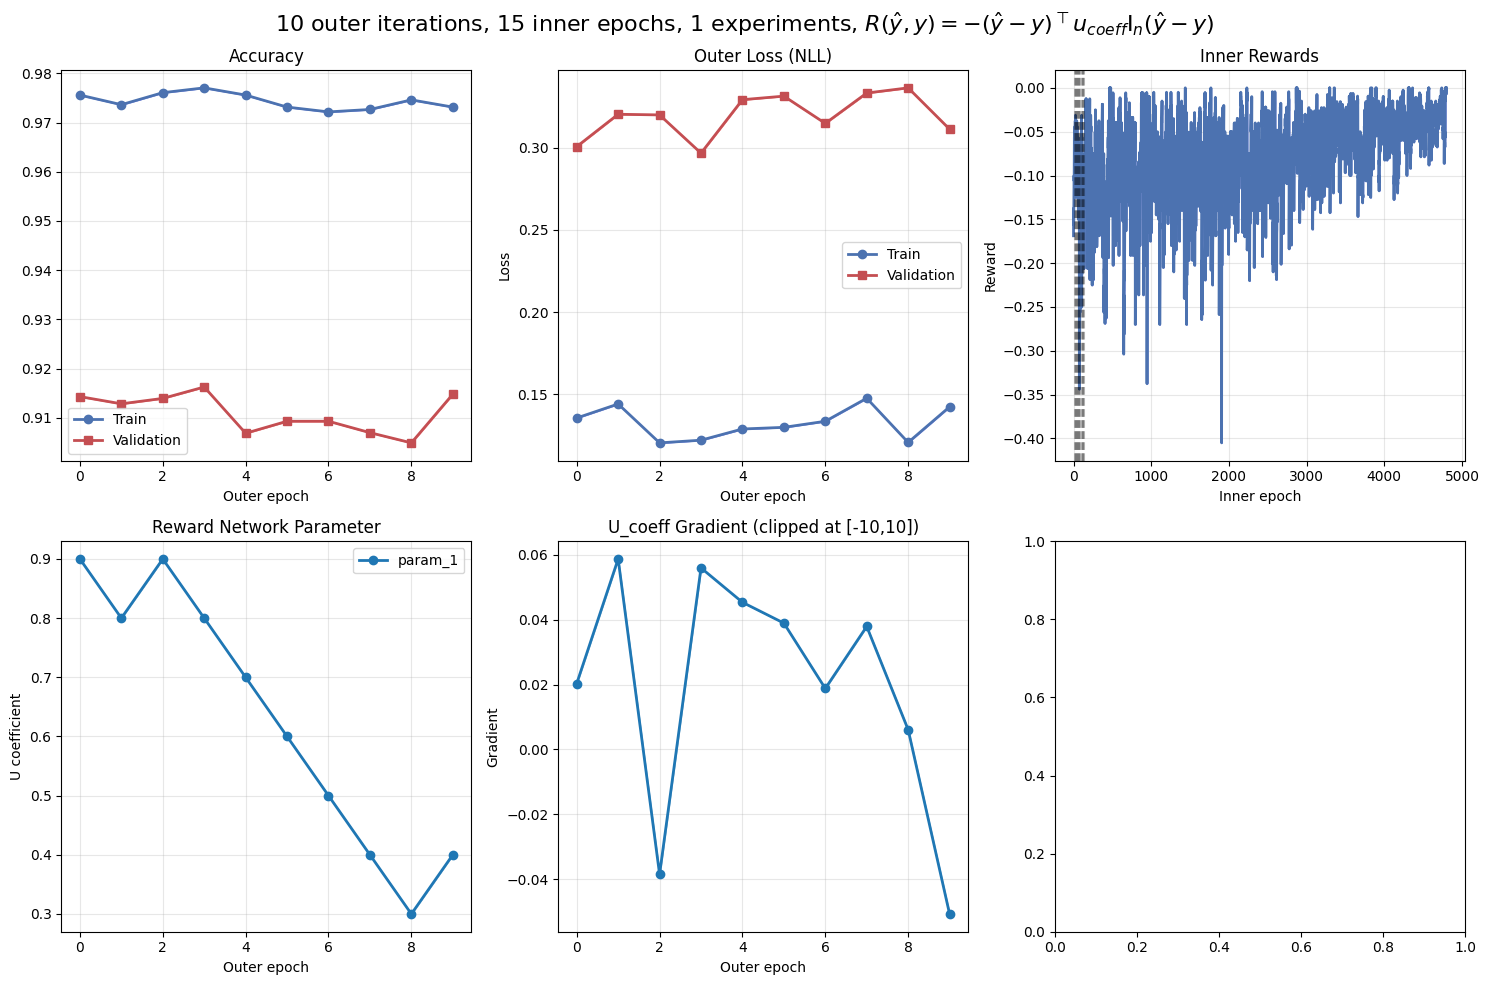

In [42]:
# Plot results with error bars
fig, ((ax0, ax1, ax2), (ax3, ax4, ax5)) = plt.subplots(2, 3, figsize=(15, 10))

# Plot accuracies (train and validation)
epochs_acc = range(len(train_accuracies_mean))
ax0.plot(
    epochs_acc, train_accuracies_mean, "b-o", linewidth=2, markersize=6, label="Train"
)
ax0.fill_between(
    epochs_acc,
    train_accuracies_mean - train_accuracies_se,
    train_accuracies_mean + train_accuracies_se,
    alpha=0.3,
    color="blue",
)
ax0.plot(
    epochs_acc,
    val_accuracies_mean,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
print(f"val losses: {val_accuracies_mean[-5:]}")
ax0.fill_between(
    epochs_acc,
    val_accuracies_mean - val_accuracies_se,
    val_accuracies_mean + val_accuracies_se,
    alpha=0.3,
    color="red",
)
ax0.set_xlabel("Outer epoch")
ax0.set_title("Accuracy")
ax0.legend()
ax0.grid(True, alpha=0.3)

# Plot outer losses (train and validation)
epochs_outer = range(len(outer_losses_mean))
ax1.plot(
    epochs_outer, outer_losses_mean, "b-o", linewidth=2, markersize=6, label="Train"
)
ax1.fill_between(
    epochs_outer,
    outer_losses_mean - outer_losses_se,
    outer_losses_mean + outer_losses_se,
    alpha=0.3,
    color="blue",
)
ax1.plot(
    epochs_outer,
    val_outer_losses_mean,
    "r-s",
    linewidth=2,
    markersize=6,
    label="Validation",
)
print(f"val losses: {val_outer_losses_mean[-5:]}")
ax1.fill_between(
    epochs_outer,
    val_outer_losses_mean - val_outer_losses_se,
    val_outer_losses_mean + val_outer_losses_se,
    alpha=0.3,
    color="red",
)
ax1.set_xlabel("Outer epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Outer Loss (NLL)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot inner rewards
epochs_inner = range(len(inner_rewards_mean))
ax2.plot(epochs_inner, inner_rewards_mean, "b-", linewidth=2)
ax2.fill_between(
    epochs_inner,
    inner_rewards_mean - inner_rewards_se,
    inner_rewards_mean + inner_rewards_se,
    alpha=0.3,
    color="blue",
)

# Add vertical dotted lines to separate outer epochs
for i in range(1, n_outer_epochs):
    if i * n_inner_epochs < len(epochs_inner):
        ax2.axvline(
            x=i * n_inner_epochs - 0.5, color="black", linestyle="--", alpha=0.3
        )

ax2.set_xlabel("Inner epoch")
ax2.set_ylabel("Reward")
ax2.set_title("Inner Rewards")
ax2.grid(True, alpha=0.3)
# Set integer ticks for x-axis
# ax2.set_xticks(range(0, len(epochs_inner), max(1, len(epochs_inner)//10)))

# Define colors from seaborn default palette
palette = sns.color_palette()  # seaborn default ("deep")
n_params = max(1, len(U_coeff_mean))
colors = [palette[j % len(palette)] for j in range(n_params)]

# Plot U coefficient
for i, (k, v) in enumerate(U_coeff_mean.items()):
    epochs_U = range(len(v))
    color = colors[i % len(colors)]
    if reward_use_softplus:
        ax3.plot(
            epochs_U,
            np.log(1 + np.exp(v)),
            "-o",
            linewidth=2,
            markersize=6,
            label=k if len(U_coeff_grad_mean) <= 4 else None,
            color=color,
        )
        ax3.fill_between(
            epochs_U,
            np.log(1 + np.exp(v - U_coeff_se[k])),
            np.log(1 + np.exp(v + U_coeff_se[k])),
            alpha=0.3,
            color=color,
        )
    else:
        ax3.plot(
            epochs_U,
            v,
            "-o",
            linewidth=2,
            markersize=6,
            label=k if len(U_coeff_grad_mean) <= 4 else None,
            color=color,
        )
        ax3.fill_between(
            epochs_U, v - U_coeff_se[k], v + U_coeff_se[k], alpha=0.3, color=color
        )
    print(f"{k}: {v[-5:]}")
# if U_hat_star is not None:
#     ax3.axhline(
#         y=U_hat_star, color="gray", linestyle="--", linewidth=2, label=r"$\hat{\mathrm{U}}^\star$"
#     )
ax3.set_xlabel("Outer epoch")
ax3.set_ylabel("U coefficient")
ax3.set_title("Reward Network Parameter")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot U coefficient gradients
for i, (k, v) in enumerate(U_coeff_grad_mean.items()):
    color = colors[i % len(colors)]
    epochs_U = range(len(v))
    ax4.plot(
        epochs_U,
        v,
        "-o",
        linewidth=2,
        markersize=6,
        label=k if len(U_coeff_grad_mean) <= 4 else None,
        color=color,
    )
    ax4.fill_between(
        epochs_U, v - U_coeff_grad_se[k], v + U_coeff_grad_se[k], alpha=0.3, color=color
    )
ax4.set_xlabel("Outer epoch")
ax4.set_ylabel("Gradient")
ax4.set_title("U_coeff Gradient (clipped at [-10,10])")
ax4.grid(True, alpha=0.3)


suptitle = f"{n_outer_epochs} outer iterations, {n_inner_epochs} inner epochs, {max_repetitions} experiments, "
suptitle += r"$R(\hat{y},y) = -(\hat{y}-y)^\top u_{coeff} \mathrm{I}_n (\hat{y}-y)$"

fig.suptitle(
    suptitle,
    fontsize=16,
    y=0.98,
)

plt.tight_layout()
plt.show()